#REGRESION LINEAL MULTIPLE CON POLINIOMIOS DE SEGUNDO Y TERCER GRADO

In [21]:
# 1) Librerias
import numpy as np      # Para trabajar con operaciones numéricas y arreglos
import pandas as pd  # Para manipular los datos en forma de tabla
import statsmodels.api as sm  # Para construir el modelo de regresión
import matplotlib.pyplot as plt  # Para graficar resultados
import statsmodels.stats.api as sms  # Para realizar pruebas estadísticas sobre el modelo (ej. heterocedasticidad)
from sklearn.preprocessing import StandardScaler  # Para escalar variables
import seaborn as sns  # Librería para visualización de dato

In [2]:
# 2) Subir archivo
from google.colab import files  # Permite subir archivos desde tu computadora

uploaded = files.upload()  # Abre la ventana para seleccionar el archivo
archivo = list(uploaded.keys())[0]  # Obtiene el nombre del archivo cargado

Saving TABLA CONJUNTA .csv to TABLA CONJUNTA .csv


El archivo que se debe cargar es un archivo en formato CSV (.csv) que contiene
todas las variables climáticas y agrícolas por zona. Esto incluye variables como
evaporación, lluvia y temperatura para distintas zonas (por ejemplo: La Barca,
Jamay, Ocotlán y Briseñas), así como las columnas de superficie sembrada y
cosechada para cada una de estas zonas.

La base de datos ya se encuentra previamente depurada y organizada, por lo que
puede ser utilizada directamente para el modelo. Este código está diseñado para
trabajar con esta estructura completa de variables, permitiendo seleccionar y
combinar distintas variables según el análisis que se quiera realizar.

In [3]:
# 3) Leer datos

df = pd.read_csv(archivo)  # Carga el archivo CSV como DataFrame
print(df.head())  # Muestra las primeras filas para verificar que se cargó correctamente

    AÑO  EVAPORACION LA BARCA   EVAPORACION JAMAY  EVAPORACION OCOTLAN  \
0  2003              131.90100         148.124000           156.121708   
1  2004              135.13450         151.439441           136.129292   
2  2005              151.41125         156.955167           157.909542   
3  2006              155.83000         155.155000           142.895833   
4  2007              143.78250         147.241941           164.998083   

   EVAPORACION BRISEÑAS  LLUVIA LA BARCA  LLUVIA JAMAY  LLUVIA OCOTLAN  \
0            164.138893        83.733333     51.394583       61.321667   
1            162.336662        89.888333     83.124782       89.691000   
2            173.203012        63.000000     43.633333       54.152875   
3            167.569167        67.458500     66.858333       53.792917   
4            166.331644        63.920000     61.891991       75.491667   

   LLUVIA BRISEÑAS   TMaxE LA BARCA  ...  TMinP OCOTLAN  TMinP BRISEÑAS  \
0         61.336751       32.541667

In [7]:
# 4)Limpieza básica de nombres de columnas

df.columns = df.columns.str.strip()  # Elimina espacios en blanco en los nombres de las columnas

In [8]:
# 5) Definir variables del modelo

# Variable dependiente (Y)
# Corresponde a la variable que se quiere explicar (producción agrícola)
y = df["Cosechada OCOTLAN"]


# Variables independientes (X)
# Se seleccionan únicamente variables climáticas relevantes para el análisis
X = df[[
    #"EVAPORACION LA BARCA",
    #"EVAPORACION JAMAY",
    "EVAPORACION OCOTLAN",
    #"EVAPORACION BRISEÑAS",

    #"LLUVIA LA BARCA",
    #"LLUVIA JAMAY",
    "LLUVIA OCOTLAN",
    #"LLUVIA BRISEÑAS",

    #"TMaxE LA BARCA",
    #"TMaxE JAMAY",
    #"TMaxE OCOTLAN",
    #"TMaxE BRISEÑAS",

    #"TMaxP LA BARCA",
    #"TMaxP JAMAY",
    #"TMaxP OCOTLAN",
    #"TMaxP BRISEÑAS",

    #"TMedP LA BARCA",
    #"TMedP JAMAY",
    "TMedP OCOTLAN",
    #"TMedP BRISEÑAS",

    #"TMinE LA BARCA",
    #"TMinE JAMAY",
    #"TMinE OCOTLAN",
    #"TMinE BRISEÑAS",

    #"TMinP LA BARCA",
    #"TMinP JAMAY",
    #"TMinP OCOTLAN",
    #"TMinP BRISEÑAS"
]]

En este bloque se definen las variables del modelo. La variable dependiente (Y) puede cambiarse dependiendo del análisis que se quiera realizar, ya sea superficie cosechada o sembrada en cualquiera de las zonas disponibles (La Barca, Jamay, Ocotlán, Briseñas). Por otro lado, las variables independientes (X) se seleccionan activando o desactivando las columnas mediante comentarios. Esto permite probar diferentes combinaciones de variables climáticas sin tener que reescribir el código, facilitando la comparación entre modelos y el análisis de qué factores tienen mayor influencia.

In [9]:
# 6) Escalar variables

scaler = StandardScaler()  # Crea el objeto que estandariza los datos
X_scaled = scaler.fit_transform(X)  # Ajusta y transforma las variables (media=0, desviación=1)

# Convertir a DataFrame para mantener nombres de columnas
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


En este bloque se realiza el escalamiento de las variables independientes utilizando la función StandardScaler. En la primera línea, scaler = StandardScaler(), se crea un objeto que define el método de estandarización, es decir, cómo se van a transformar los datos. Posteriormente, en X_scaled = scaler.fit_transform(X), el modelo primero “aprende” la media y la desviación estándar de cada variable (fit) y después transforma los datos (transform), logrando que todas las variables tengan media igual a cero y desviación estándar igual a uno.

Este proceso es importante en modelos polinomiales, ya que al elevar las variables al cuadrado o al cubo, sus valores pueden crecer considerablemente y generar desbalances en el modelo. Al estandarizar las variables, se asegura que todas tengan la misma escala, lo que permite una mejor estimación de los coeficientes y mayor estabilidad en el modelo.

Finalmente, se convierte el resultado nuevamente a un DataFrame para conservar los nombres originales de las columnas, lo cual facilita la interpretación y el manejo de los datos en las siguientes etapas del análisis.

Es importante destacar que este proceso se aplica únicamente a las variables independientes (X), mientras que la variable dependiente (Y) no se escala. Esto se debe a que la variable objetivo representa el valor que se desea explicar, por lo que mantener su escala original facilita la interpretación de los resultados del modelo.

Este enfoque es consistente con lo señalado en textos de análisis estadístico, donde se recomienda estandarizar las variables explicativas cuando existen diferencias importantes en sus magnitudes o cuando se utilizan transformaciones no lineales, como en el caso de modelos polinomiales (James et al., 2013).

In [10]:
print(X_scaled.head())  # Muestra las primeras filas de las variables ya escaladas para verificar la transformación

   EVAPORACION OCOTLAN  LLUVIA OCOTLAN  TMedP OCOTLAN
0             1.135869       -0.505864      -0.158714
1            -0.021916        1.259620      -0.711810
2             1.239405       -0.951993       0.162595
3             0.369943       -0.974394      -0.087235
4             1.649911        0.375965       0.273631


In [11]:
# 7) Regresión polinomial de segundo grado

X2 = X_scaled.copy()  # Copia de las variables escaladas

# Crear términos cuadrados
for col in X_scaled.columns:
    X2[col + "_2"] = X_scaled[col]**2  # Genera una nueva variable con el cuadrado de cada variable original

# Agregar constante
X2 = sm.add_constant(X2)  # Incluye el intercepto en el modelo

# Ajustar modelo
modelo_2 = sm.OLS(y, X2).fit()  # Ajusta el modelo de regresión de segundo grado

print(modelo_2.summary())  # Muestra el resumen estadístico del modelo

                            OLS Regression Results                            
Dep. Variable:      Cosechada OCOTLAN   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                     2.968
Date:                Thu, 30 Apr 2026   Prob (F-statistic):             0.0408
Time:                        02:22:12   Log-Likelihood:                -195.56
No. Observations:                  22   AIC:                             405.1
Df Residuals:                      15   BIC:                             412.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  9747.02

En este bloque, primero se crea X2 = X_scaled.copy(), que hace una copia de las variables independientes ya escaladas. Esto significa que el modelo empieza conservando las variables originales en su forma lineal.

Después, con el ciclo for col in X_scaled.columns, el código recorre cada una de las columnas de X_scaled. En cada vuelta, la línea X2[col + "_2"] = X_scaled[col]**2 crea una nueva columna elevada al cuadrado, agregando así los términos cuadráticos al modelo.

Luego, X2 = sm.add_constant(X2) agrega la constante o intercepto, para que el modelo no esté obligado a pasar por el origen. Finalmente, modelo_2 = sm.OLS(y, X2).fit() ajusta la regresión polinomial de segundo grado usando OLS, y print(modelo_2.summary()) muestra el resumen estadístico del modelo.

Es normal que en el resultado aparezcan tanto las variables originales como las variables al cuadrado. La regresión polinomial no sustituye la parte lineal, sino que la complementa: las variables lineales capturan la relación básica, mientras que los términos cuadráticos permiten detectar posibles curvaturas o efectos no lineales.

In [14]:
# 8) Validación del modelo (grado 2)

from scipy.stats import shapiro  # Prueba de normalidad
from statsmodels.stats.stattools import durbin_watson  # Prueba de autocorrelación

# Prueba de normalidad (Shapiro-Wilk)
stat, p_shapiro = shapiro(modelo_2.resid)  # Evalúa si los errores siguen una distribución normal

# Prueba de heterocedasticidad (Breusch-Pagan)
test = sms.het_breuschpagan(modelo_2.resid, X2)  # Evalúa si la varianza de los errores es constante
p_bp = test[1]  # p-value de la prueba

# Prueba de autocorrelación (Durbin-Watson)
dw = durbin_watson(modelo_2.resid)  # Evalúa si existe correlación entre los errores

# Resultados de las pruebas
print(f"Shapiro-Wilk (normalidad): {p_shapiro}")
print(f"Durbin-Watson (autocorrelación): {dw}")
print(f"Breusch-Pagan (heterocedasticidad): {p_bp}")

Shapiro-Wilk (normalidad): 0.9182622087023187
Durbin-Watson (autocorrelación): 1.3156313979255856
Breusch-Pagan (heterocedasticidad): 0.1545752444289908


Para evaluar la validez del modelo, se aplicaron tres pruebas estadísticas. La prueba de Shapiro-Wilk permite verificar si los errores del modelo siguen una distribución normal, lo cual es un supuesto importante en regresión. La prueba de Breusch-Pagan se utiliza para analizar si la varianza de los errores es constante, es decir, si existe o no heterocedasticidad. Finalmente, el estadístico de Durbin-Watson evalúa si hay autocorrelación entre los errores, donde valores cercanos a 2 indican independencia. En conjunto, estas pruebas permiten determinar si el modelo cumple con los supuestos básicos y si sus resultados pueden considerarse confiables.

In [15]:
# 9) Regresión polinomial de tercer grado

X3 = X_scaled.copy()  # Copia de las variables escaladas

# Crear términos cuadrados y cúbicos
for col in X_scaled.columns:
    X3[col + "_2"] = X_scaled[col]**2  # Término cuadrático
    X3[col + "_3"] = X_scaled[col]**3  # Término cúbico

# Agregar constante
X3 = sm.add_constant(X3)  # Incluye el intercepto

# Ajustar modelo
modelo_3 = sm.OLS(y, X3).fit()  # Ajusta el modelo de tercer grado

print(modelo_3.summary())  # Muestra resultados del modelo

                            OLS Regression Results                            
Dep. Variable:      Cosechada OCOTLAN   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     1.731
Date:                Thu, 30 Apr 2026   Prob (F-statistic):              0.185
Time:                        02:38:18   Log-Likelihood:                -195.01
No. Observations:                  22   AIC:                             410.0
Df Residuals:                      12   BIC:                             420.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  9599.50

En este bloque, primero se crea una copia de las variables independientes escaladas mediante X3 = X_scaled.copy(), conservando así las variables originales en su forma lineal. Posteriormente, mediante un ciclo for, se generan nuevas variables elevando cada columna al cuadrado y al cubo, lo que permite incorporar términos cuadráticos y cúbicos al modelo.

En los modelos de regresión polinomial de orden superior, como el de tercer grado, es necesario incluir de manera conjunta los términos lineales, cuadrados y cúbicos. Esto se debe a que cada uno de estos componentes captura distintos niveles de relación entre las variables: el término lineal describe la tendencia básica, el término cuadrático permite modelar curvaturas, y el término cúbico introduce mayor flexibilidad para representar comportamientos más complejos.

Excluir alguno de estos términos puede llevar a una especificación incorrecta del modelo, ya que se omite parte de la estructura funcional necesaria para describir adecuadamente la relación entre las variables. Por esta razón, los modelos polinomiales se construyen de forma jerárquica, incluyendo todos los términos hasta el grado deseado (Montgomery, Peck, & Vining, 2012).

In [16]:
# 10) Validación del modelo (grado 3)

from scipy.stats import shapiro  # Prueba de normalidad
from statsmodels.stats.stattools import durbin_watson  # Prueba de autocorrelación

# Prueba de normalidad (Shapiro-Wilk)
stat, p_shapiro = shapiro(modelo_3.resid)  # Evalúa si los errores siguen una distribución normal

# Prueba de heterocedasticidad (Breusch-Pagan)
test = sms.het_breuschpagan(modelo_3.resid, X3)  # Evalúa si la varianza de los errores es constante
p_bp = test[1]  # p-value de la prueba

# Prueba de autocorrelación (Durbin-Watson)
dw = durbin_watson(modelo_3.resid)  # Evalúa si existe correlación entre los errores

# Resultados de las pruebas
print(f"Shapiro-Wilk (normalidad): {p_shapiro}")
print(f"Durbin-Watson (autocorrelación): {dw}")
print(f"Breusch-Pagan (heterocedasticidad): {p_bp}")

Shapiro-Wilk (normalidad): 0.7300860166072074
Durbin-Watson (autocorrelación): 1.4298714651359
Breusch-Pagan (heterocedasticidad): 0.3176017598184588


Para validar el modelo de tercer grado, se aplicaron las mismas pruebas estadísticas que en los modelos anteriores. La prueba de Shapiro-Wilk permite verificar si los errores siguen una distribución normal, la prueba de Breusch-Pagan evalúa si la varianza de los errores es constante, y el estadístico de Durbin-Watson analiza si existe autocorrelación. Estas pruebas permiten confirmar si el modelo cumple con los supuestos básicos de la regresión y si sus resultados son consistentes.

#GRAFICAS Y APOYOS VISUALES RELACIONANDO LA COSECHA DE MAIZ Y LAS CONDICIONES CLIMATICAS

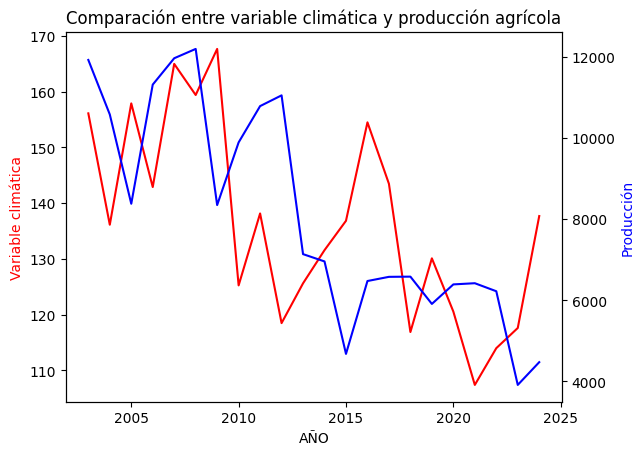

In [18]:
# 1) Gráfica de doble eje (comparación entre variables)

fig, ax1 = plt.subplots()  # Crea la figura y el primer eje

# Eje izquierdo (variable climática)
ax1.set_xlabel("AÑO")
ax1.set_ylabel("Variable climática", color="red")  # Etiqueta general

ax1.plot(df["AÑO"], df["EVAPORACION OCOTLAN"], color="red")  # Línea de la variable climática
ax1.tick_params(axis='y')

# Eje derecho (variable agrícola)
ax2 = ax1.twinx()  # Crea un segundo eje que comparte el mismo eje X

ax2.set_ylabel("Producción", color="blue")  # Etiqueta general
ax2.plot(df["AÑO"], df["Cosechada OCOTLAN"], color="blue")  # Línea de la producción

plt.title("Comparación entre variable climática y producción agrícola")
plt.show()

En esta gráfica, el eje izquierdo (Y1) puede adaptarse para mostrar cualquier variable climática disponible en la base de datos, utilizando el nombre exacto de la columna correspondiente. De la misma forma, en el eje derecho (Y2) se puede seleccionar cualquier variable relacionada con la producción de maíz, como superficie sembrada o cosechada, simplemente cambiando el nombre de la variable. Esto permite comparar distintas combinaciones sin necesidad de modificar la estructura del código.

                     Cosechada OCOTLAN  EVAPORACION OCOTLAN  LLUVIA OCOTLAN  \
Cosechada OCOTLAN             1.000000             0.462347        0.195607   
EVAPORACION OCOTLAN           0.462347             1.000000       -0.105801   
LLUVIA OCOTLAN                0.195607            -0.105801        1.000000   
TMedP OCOTLAN                -0.089523             0.240519       -0.141077   

                     TMedP OCOTLAN  
Cosechada OCOTLAN        -0.089523  
EVAPORACION OCOTLAN       0.240519  
LLUVIA OCOTLAN           -0.141077  
TMedP OCOTLAN             1.000000  


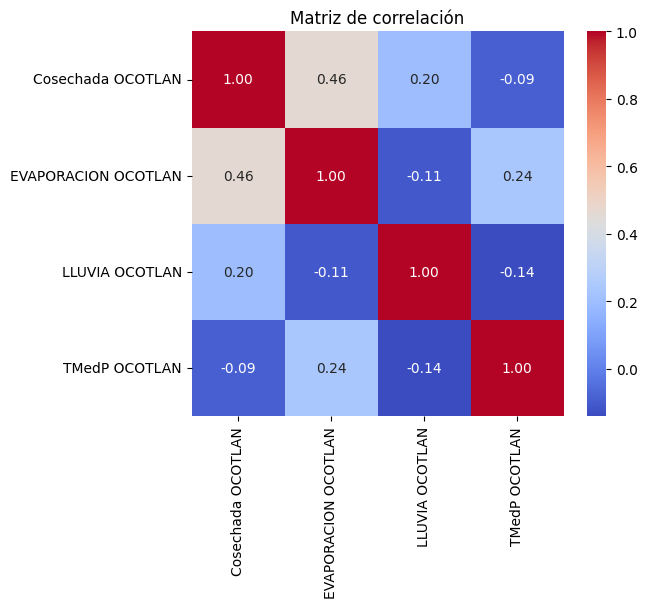

In [20]:
# 2) Matriz de correlación

# Seleccionar variables de interés
corr_df = df[[
    "Cosechada OCOTLAN",
    "EVAPORACION OCOTLAN",
    "LLUVIA OCOTLAN",
    "TMedP OCOTLAN"
]]

# Calcular correlación
corr = corr_df.corr()  # Calcula la correlación entre todas las variables seleccionadas
print(corr)  # Muestra la matriz numérica de correlación

# Heatmap de la matriz de correlación
plt.figure(figsize=(6,5))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")  # Visualiza la correlación con colores
plt.title("Matriz de correlación")
plt.show()

se seleccionan las variables de interés dentro del DataFrame original y se almacenan en corr_df, con el fin de trabajar únicamente con esas columnas. Después, mediante corr_df.corr(), se calcula la matriz de correlación, la cual mide la relación lineal entre cada par de variables. Esta matriz se imprime en consola para observar los valores numéricos. Luego, se define el tamaño de la gráfica con plt.figure, y se genera el heatmap con sns.heatmap, donde los colores representan la intensidad de la correlación y los valores se muestran dentro de cada celda. Finalmente, se agrega un título a la gráfica y se muestra el resultado, permitiendo una interpretación visual más clara de las relaciones entre las variables seleccionadas.

En la matriz de correlación, los valores van de -1 a 1. Un valor cercano a 1 indica una correlación positiva fuerte, es decir, ambas variables aumentan juntas. Un valor cercano a -1 indica una correlación negativa, donde una variable aumenta mientras la otra disminuye. Por otro lado, valores cercanos a 0 sugieren que no existe una relación lineal significativa entre las variables.

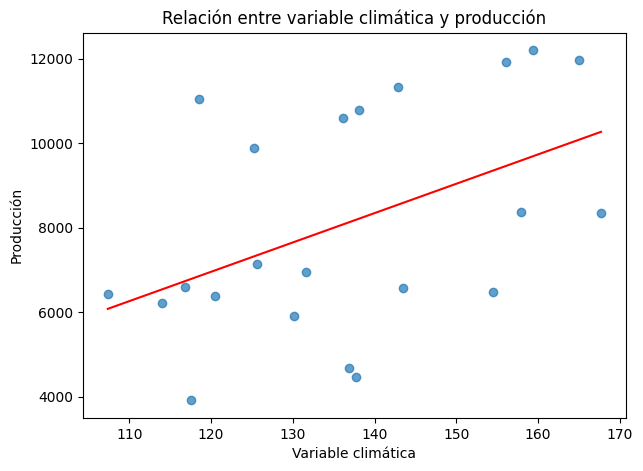

In [23]:
# 3) Relación entre variables (scatter + línea de tendencia)

x = df["EVAPORACION OCOTLAN"]  # Variable independiente (climática)
y = df["Cosechada OCOTLAN"]  # Variable dependiente (producción)

plt.figure(figsize=(7,5))  # Tamaño de la gráfica

plt.scatter(x, y, alpha=0.7)  # Gráfica de dispersión (puntos)

# Línea de tendencia (regresión simple)
coef = np.polyfit(x, y, 1)  # Ajusta una recta (grado 1)
y_line = coef[0]*x + coef[1]  # Calcula los valores de la recta

# Ordenar valores para que la línea se vea continua
orden = x.argsort()

plt.plot(x.iloc[orden], y_line.iloc[orden], color="red")  # Dibuja la línea de tendencia

plt.xlabel("Variable climática")
plt.ylabel("Producción")
plt.title("Relación entre variable climática y producción")

plt.show()

En este bloque se analiza la relación entre dos variables mediante una gráfica de dispersión y una regresión lineal simple. Primero, se definen las variables x y y, donde x representa la variable independiente (evaporación) y y la variable dependiente (cosecha). Luego, se crea la gráfica con plt.figure y plt.scatter, lo que permite visualizar cómo se distribuyen los datos. Posteriormente, con np.polyfit(x, y, 1) se ajusta una recta de grado 1, obteniendo los coeficientes de la regresión, es decir, la pendiente y el intercepto. Con estos coeficientes se construye la línea de tendencia mediante y_line = coef[0]*x + coef[1]. Después, se ordenan los valores de x para que la línea se dibuje de forma continua y no desordenada, y finalmente se grafica esta línea junto con los datos originales. Es importante señalar que este método corresponde a una regresión lineal simple, útil para visualizar la relación entre las variables; sin embargo, a diferencia de métodos como OLS, no proporciona un análisis estadístico completo, sino únicamente un ajuste visual de la tendencia.

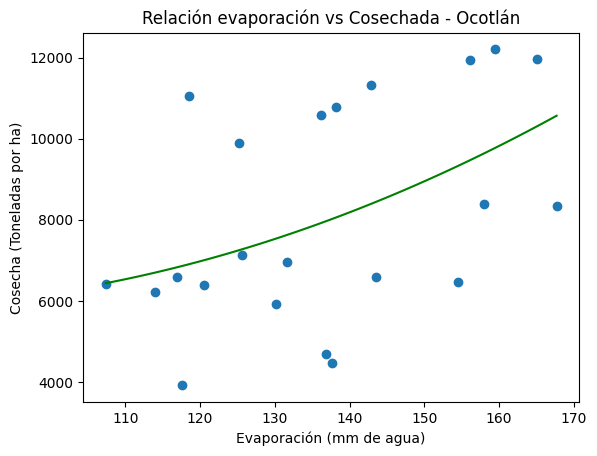

In [24]:
# 4) Relación con ajuste polinomial de grado 2

coef2 = np.polyfit(x, y, 2)  # Ajusta un modelo cuadrático (grado 2)

x_range = np.linspace(x.min(), x.max(), 100)  # Genera valores continuos en el rango de x
y_curve = coef2[0]*x_range**2 + coef2[1]*x_range + coef2[2]  # Calcula la curva

plt.scatter(x, y)  # Puntos originales
plt.plot(x_range, y_curve, color="green")  # Curva ajustada

plt.xlabel("Evaporación (mm de agua)")
plt.ylabel("Cosecha (Toneladas por ha)")
plt.title("Relación evaporación vs Cosechada - Ocotlán")

plt.show()

En este bloque se construye un ajuste polinomial de segundo grado para analizar la relación entre las variables. Primero, con np.polyfit(x, y, 2) se calcula una regresión cuadrática, obteniendo los coeficientes de una función de grado 2. Posteriormente, se genera un rango continuo de valores con np.linspace, lo que permite dibujar una curva suave en lugar de puntos discretos. Con estos valores, se calcula la función cuadrática mediante y_curve, incorporando los términos al cuadrado, lineales y constantes. Finalmente, se grafican los datos originales junto con la curva ajustada, lo que permite visualizar una posible relación no lineal entre las variables. Al igual que en el caso anterior, este método proporciona un ajuste visual de la tendencia, pero no incluye un análisis estadístico completo como el que se obtiene con modelos de regresión más formales.

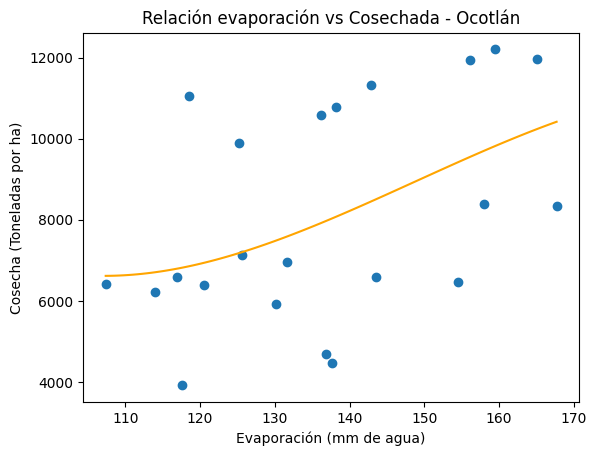

In [25]:
# 5) Relación con ajuste polinomial de grado 3

coef3 = np.polyfit(x, y, 3)  # Ajusta un modelo cúbico (grado 3)

x_range = np.linspace(x.min(), x.max(), 100)  # Genera valores continuos en el rango de x
y_curve = coef3[0]*x_range**3 + coef3[1]*x_range**2 + coef3[2]*x_range + coef3[3]  # Calcula la curva cúbica

plt.scatter(x, y)  # Puntos originales
plt.plot(x_range, y_curve, color="orange")  # Curva ajustada

plt.xlabel("Evaporación (mm de agua)")
plt.ylabel("Cosecha (Toneladas por ha)")
plt.title("Relación evaporación vs Cosechada - Ocotlán")

plt.show()

En este bloque se construye un ajuste polinomial de tercer grado para analizar la relación entre las variables. Primero, con np.polyfit(x, y, 3) se calcula una regresión cúbica, obteniendo los coeficientes de una función de grado 3. Posteriormente, se genera un conjunto de valores continuos mediante np.linspace, lo que permite representar la curva de forma suave. Con estos valores, se calcula la función cúbica incorporando términos al cubo, al cuadrado, lineales y constantes. Finalmente, se grafican los datos originales junto con la curva ajustada, lo que permite visualizar relaciones más complejas que no pueden ser capturadas por una recta o una parábola. Al igual que en los casos anteriores, este método proporciona un ajuste visual de la tendencia, pero no incluye un análisis estadístico completo.